In [ ]:
import os
import h5py 
import torch 
import numpy as np
from torch.nn.functional import interpolate
from pathlib import Path

input_dir = '/home/mim-server/datasets/pushT/224/'
output_dir = '/home/mim-server/datasets/pushT/sharded/'
input_files = os.listdir(input_dir)
shard_file = input_files[0]  

input_data_path = os.path.join(input_dir, shard_file)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

def loadPushTData(data_path):
    with h5py.File(data_path, 'r') as f:
        data = f
        actions = data['actions'][:]
        images = data['cam1'][:]
    images = torch.from_numpy(images).float()
    images = interpolate(images, size=(256,256), mode='bilinear', align_corners=False)
    images = images.permute(0, 2, 3, 1)  # NHWC to NCHW
    images = (images*255).to(torch.uint8)
    return actions[None], images[None].numpy()

def saveShardedData(output_path, actions, images):
    with h5py.File(output_path, 'w') as f:
        comp_args = {'compression': 'gzip', 'compression_opts': 4}
        image_shape = images.shape[2:]
        action_shape = actions.shape[2:]
        images_ds = f.create_dataset('images', shape=images.shape, dtype=np.uint8, chunks=(1, 128, *image_shape), **comp_args)
        actions_ds = f.create_dataset('actions', shape=actions.shape, dtype=np.float32, chunks=(1, 128, *action_shape), **comp_args)
        f.create_dataset('episode_lengths', data=np.array([images.shape[1]], dtype=np.int32))
        f.attrs['num_episodes'] = images.shape[1]
        images_ds[:] = images
        actions_ds[:] = actions

In [ ]:
for i, data_file in enumerate(input_files):
    print(f"Processing file {i+1}/{len(input_files)}: {data_file}")
    input_data_path = os.path.join(input_dir, data_file)
    output_data_path = os.path.join(output_dir, f"shard_{i:04d}.h5")
    actions, images = loadPushTData(input_data_path)
    print(f"  Loaded data shape - actions: {actions.shape}, images: {images.shape}")
    saveShardedData(output_data_path, actions, images)

In [ ]:
str(output_dir)

In [ ]:
from dreamerv4.datasets import ShardedHDF5Dataset

dataset = ShardedHDF5Dataset(str(output_dir), window_size=192, stride=1)

In [ ]:
import torch 
from dreamerv4.datasets import ShardedHDF5Dataset
from dreamerv4.models.utils import load_tokenizer
from dreamerv4.models.utils import load_denoiser
from dreamerv4.models.dynamics import DenoiserWrapper
from dreamerv4.models.tokenizer import TokenizerWrapper
from hydra import initialize, compose
from omegaconf import OmegaConf
with initialize(version_base=None, config_path="scripts/config"):
    cfg = compose(config_name="dynamics/pushT.yaml")

model = DenoiserWrapper(cfg)
# model = TokenizerWrapper(cfg)

In [ ]:
import torch

ckpt_path = "/home/mim-server/projects/rooholla/dreamer-v4-draft/checkpoints/dynamics_ckpts/video-pushT-110M.pt"
state = torch.load(ckpt_path, map_location='cpu')
if 'dyn' in state.keys():
    sd = state['dyn']
else:
    sd = state['model']
    
to_delete = []
clean_sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
for k in clean_sd.keys():
    if k.endswith("cos_emb") or k.endswith("sin_emb") or "temporal_mask_full" in k:
        to_delete.append(k)
for k in to_delete:
    del clean_sd[k]

spell_corrrected = {}
for key in clean_sd.keys():
    val = clean_sd[key]
    if 'diffuion' in key:
        key = key.replace('diffuion', 'diffusion')
        print(key)

    spell_corrrected[key]=val

clean_sd = spell_corrrected

state['model'] = clean_sd
if 'model' not in state.keys():
    clean_sd = {'model.'+k: v for k, v in clean_sd.items()}
    state['model'] = clean_sd
if 'dyn' in state.keys():
    del state['dyn']



print(state.keys())
print(state['model'].keys())

In [ ]:
model.load_state_dict(state['model'], strict=True)


In [ ]:
torch.save(state, ckpt_path)

In [1]:
'''
For licensing see accompanying LICENSE.txt file.
Copyright (C) 2025 Apple Inc. All Rights Reserved.

A simple PyTorch dataset using torchcodec for MP4 files and h5py for HDF5 files.
'''

import h5py
import numpy as np
import torch
from dreamerv4.egoDext.utils.data_utils import index_episodes
from torchcodec.decoders import VideoDecoder
from dreamerv4.egoDext.utils.skeleton_tfs import DEFAULT_TFS, WM_TFS

# loads only the wrist transforms by default. change as desired.
# DEFAULT_QUERY_TFS = DEFAULT_TFS
DEFAULT_QUERY_TFS = WM_TFS

class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path, query_tfs=DEFAULT_QUERY_TFS):
        # a list of transforms that the dataset will return
        self.query_tfs = query_tfs

        # get episode paths and lengths
        self.dataset_path_list, self.episode_len = index_episodes(dataset_path)
        self.cumulative_len = np.cumsum(self.episode_len)

    def __len__(self):
        return sum(self.episode_len)
    
    def _locate_transition(self, index):
        # find a particular data point within an episode
        assert index < self.cumulative_len[-1]
        episode_index = np.argmax(self.cumulative_len > index)  # argmax returns first True index
        start_ts = index - (self.cumulative_len[episode_index] - self.episode_len[episode_index])
        return episode_index, start_ts
    
    def __getitem__(self, index):
        episode_id, frame_id = self._locate_transition(index)
        hdf5_file = self.dataset_path_list[episode_id]
        mp4_file = hdf5_file[:-5] + '.mp4'

        # grab info from HDF5
        with h5py.File(hdf5_file, "r") as root:
            tfdtype = root['/transforms/camera'][0].dtype 
            # get SE(3) transforms. Note: all transforms (including camera extrinsics) are expressed in the ARKit origin frame, 
            # which is a stationary frame on the ground that is set at the beginning of a recording session. 
            # the exact position and orientation of the origin frame depends on how the Vision Pro is initialized. 
            # you may want to instead express the transforms in the camera frame (see utils.data_utils.convert_to_camera_frame). 
            # you may also want to grab a "chunk" of N transforms with root['/transforms/'+tf_name][frame_id:frame_id+N] instead of just one. 
            tfs = np.zeros([len(self.query_tfs), 4, 4], dtype=tfdtype)
            for i, tf_name in enumerate(self.query_tfs):
                tfs[i] = root['/transforms/' + tf_name][frame_id]

            cam_ext = root['/transforms/camera'][frame_id] # extrinsics
            cam_int = root['/camera/intrinsic'][:] # intrinsics

            # natural language description of task
            if root.attrs['llm_type'] == 'reversible':
                direction = root.attrs['which_llm_description']
                lang_instruct = root.attrs['llm_description' if direction == '1' else 'llm_description2'] 
            else:
                lang_instruct = root.attrs['llm_description'] 

            # add joint prediction confidences, if present in this HDF5
            confs = None
            if 'confidences' in root.keys():
                confs = np.zeros([len(self.query_tfs)], dtype=tfdtype)
                for i, tf_name in enumerate(self.query_tfs):
                    confs[i] = root['/confidences/' + tf_name][frame_id]

        # grab image frame
        img = VideoDecoder(mp4_file, device='cpu')[frame_id]
        return tfs, cam_ext, cam_int, img, lang_instruct, confs


dataset = SimpleDataset("/media/mim-server/5a9b3378-c509-41de-b07f-544b25e6a481/EgoDext/EgoDext")

Found 314839 hdf5 files


iterating dataset_path to get all episode lengths...:   3%|▎         | 9756/314839 [01:50<57:35, 88.29it/s]  


KeyboardInterrupt: 

In [2]:
import os
import rerun as rr
import numpy as np
from scipy.spatial.transform import Rotation as R
import numpy as np

class Visualizer:
    def __init__(self, app_name="RerunVisualizer", log_time_label='logtime', spawn=True, port=9876):
        # Initialize Rerun session
        if spawn == False:
            rr.init(app_name, spawn=False)
            rr.connect(f'127.0.0.1:{port}')
        else:
            rr.init(app_name, spawn=True)
        self.log_time_label = log_time_label
    
    def logPoints(self, points, colors=None, radii=None, log_path='/points', log_time=None):
        ps = []
        cs = []
        rs = []
        if colors is None:
            colors = [[0, 255, 0]] * points.shape[0]
        if radii is None:
            radii = [0.002] * points.shape[0]

        rr.log(log_path, rr.Points3D(points, colors = colors, radii=radii))   
    
    def logCoordinateFrame(self, world_T_frame, log_path, axis_length=0.2, log_time=None):
        rr.log(log_path, rr.ViewCoordinates.LEFT_HAND_Z_UP, static=True)  # Set an up-axis
        rr.log(
            f"{log_path}",
            rr.Arrows3D(
                vectors=[[axis_length, 0, 0], [0, axis_length, 0], [0, 0, axis_length]],
                colors=[[255, 0, 0], [0, 255, 0], [0, 0, 255]],
                radii = [axis_length/30, axis_length/30, axis_length/30]
            ),
        )
        xyzw = R.from_matrix(world_T_frame[0:3,0:3]).as_quat()
        quat = rr.Quaternion.identity()
        quat.xyzw = xyzw
        rr.log(log_path, rr.Transform3D(translation=world_T_frame[:3,-1].squeeze(), rotation=quat))


In [3]:
ends = dataset.cumulative_len[:].tolist()
starts = [0]+dataset.cumulative_len[:-1].tolist()

NameError: name 'dataset' is not defined

In [ ]:
vis = Visualizer()

In [61]:
end-start

44

In [67]:
import cv2 
import time

name_to_idx = {name:i for i, name in enumerate(dataset.query_tfs)}
origin_frame = 'spine7'
# origin_frame_idx = name_to_idx[origin_frame]
source_fps=30
target_fps=10

N=1324
start = starts[N]
end = ends[N]

# Preprocess Episode
body_vels = []
body_poses = []
imgs = []
tfs, cam_ext, cam_int, img, lang_instruct, confs = dataset[start]
w_T_origin_prev = torch.from_numpy(cam_ext).clone()
for i in range(start, end):
    if i% int(source_fps//target_fps)==0:
        tfs, cam_ext, cam_int, img, lang_instruct, confs = dataset[i]
        img = img.permute(1,2,0).numpy()
        
        Ts = torch.from_numpy(tfs.copy())
        # w_T_origin = Ts[origin_frame_idx]
        w_T_origin = torch.from_numpy(cam_ext)
        origin_T_w = torch.inverse(w_T_origin)[None]
        origin_Ts = torch.bmm(origin_T_w.repeat(Ts.shape[0], 1, 1), Ts)
        delta_pose = torch.inverse(w_T_origin_prev.squeeze())@w_T_origin.squeeze()
        w_T_origin_prev = w_T_origin.clone()
        lin_vel = (target_fps*delta_pose[:3, -1]).tolist()
        ang_vel =( delta_pose[[0, 0, 1],[1,2,2]]*torch.tensor([-1, 1, -1])*target_fps).tolist()
        body_vels.append(lin_vel+ang_vel)  
        body_poses.append(origin_Ts.numpy().copy())
        img = cv2.resize(img, (480, 270))
        imgs.append(img.copy().copy())

        # Visualize
        # for i, frame_name in enumerate(dataset.query_tfs):
        #     T = origin_Ts[i]
        #     vis.logCoordinateFrame(T, f'world/{frame_name}', axis_length=0.02)
        # vis.logCoordinateFrame(np.eye(4), f'world/origin', axis_length=0.02)
        img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cv2.imshow('data', img_vis)
        cv2.waitKey(1000//target_fps)
        cv2.waitKey(1)

body_vels = torch.tensor(body_vels)
body_poses = np.stack(body_poses)
actions = body_poses[:, :, :3, 1:].reshape(body_poses.shape[:-3] + (-1,))
actions = np.concat([actions, body_vels], axis=-1)
imgs = np.stack(imgs)

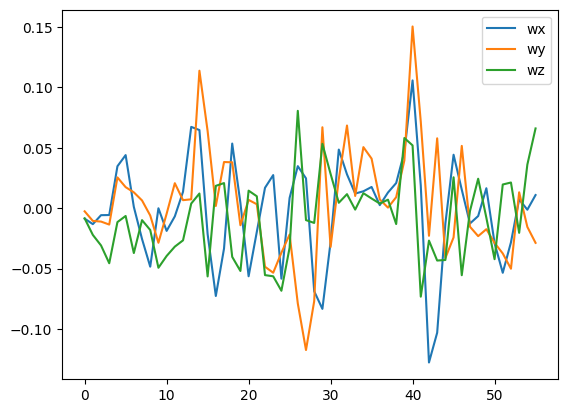

In [68]:
import matplotlib.pyplot as plt
plt.plot(body_vels[:, 3:])
# plt.ylim(-0.01, 0.01)
plt.legend(['wx', 'wy', 'wz'])

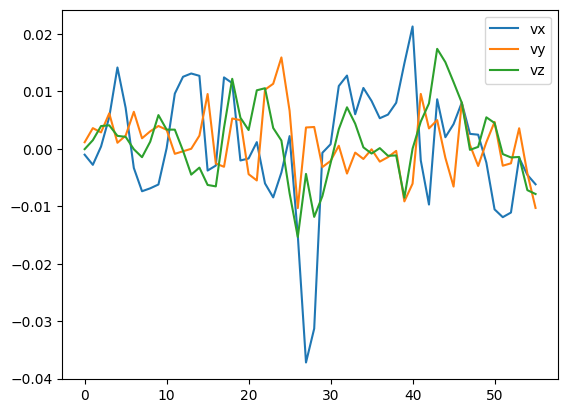

In [69]:
plt.plot(body_vels[:, :3])
# plt.ylim(-0.002, 0.002)
plt.legend(['vx', 'vy', 'vz'])

In [ ]:
(1920/1080)*256, (640/480)*256

In [ ]:
K=4
P=16
H, W = 1920/K, 1080/K
print(f'Image resolution is {H, W} --> {(H*W)/P**2} ({H/P, W/P})')

